# Statistics analysis

This notebook averages repeated executions only when all recorded grid-search parameters match. It then compares the best averaged configuration for each implementation and dataset type, and keeps the scaling comparison separate from the grid-search comparison.

In [14]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

CSV_PATTERN = "hashjoin_*.csv"
RESULTS_CANDIDATES = [Path("results"), Path("src/results"), Path("../results")]
OLD_RESULTS_CANDIDATES = [Path("old_results"), Path("src/old_results"), Path("../old_results")]

GRID_TO_RESULT_COLUMNS = {
    "N_VALUES": ["nr", "ns"],
    "P_VALUES": ["p", "num_partitions", "partition_count"],
    "SEED_VALUES": ["seed"],
    "MAX_KEY_VALUES": ["max_key"],
    "DATASET_TYPE_VALUES": ["dataset_type"],
    "NODE_VALUES": ["mpi_nodes"],
    "MPI_PROCESS_VALUES": ["mpi_processes", "mpi_world_size", "mpi_active_ranks"],
    "MPI_PARTITION_STRATEGY_VALUES": ["mpi_partition_strategy"],
    "PARTITION_THREAD_VALUES": ["partition_threads"],
    "JOIN_THREAD_VALUES": ["join_threads"],
    "PARTITION_SCHEDULE_VALUES": ["partition_schedule"],
    "JOIN_SCHEDULE_VALUES": ["join_schedule"],
    "PARTITION_CHUNK_VALUES": ["partition_chunk"],
    "JOIN_CHUNK_VALUES": ["join_chunk"],
    "PARTITION_BLOCK_SIZE_VALUES": ["partition_block_size"],
    "PARTITION_TASK_GRAIN_VALUES": ["partition_task_grain"],
    "JOIN_TASK_GRAIN_VALUES": ["join_task_grain"],
    "OFFSET_TASK_GRAIN_VALUES": ["offset_task_grain"],
}

NUMERIC_COLUMNS = [
    "checksum1", "checksum2", "join_count", "join_threads", "join_throughput",
    "join_time", "max_key", "nr", "ns", "p", "num_partitions",
    "mpi_nodes", "mpi_processes", "mpi_world_size", "mpi_active_ranks",
    "partition_threads", "partition_throughput", "partition_time", "time_sec",
    "tot_sec", "total_throughput", "partition_chunk", "join_chunk",
    "partition_block_size", "partition_task_grain", "join_task_grain",
    "offset_task_grain", "redistribution_time", "redistribution_throughput",
    "skew_fraction", "skew_partition_fraction", "seed",
]

EXEC_TYPE_ORDER = ["seq", "omp", "mpi", "hybrid", "omp_loop", "omp_loop_wb", "omp_task", "omp_task_wb", "omp_taskloop", "omp_taskloop_wb"]


def first_existing_dir(candidates):
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


def find_csv_files(candidates, pattern):
    for candidate_dir in candidates:
        candidate_files = sorted(candidate_dir.glob(pattern))
        if candidate_files:
            return candidate_dir, candidate_files
    return None, []


def normalize_frame(frame):
    frame = frame.copy()
    if "tot_sec" not in frame.columns and "time_sec" in frame.columns:
        frame["tot_sec"] = frame["time_sec"]
    if "time_sec" not in frame.columns and "tot_sec" in frame.columns:
        frame["time_sec"] = frame["tot_sec"]
    if "dataset_type" not in frame.columns:
        frame["dataset_type"] = "uniform"

    for col in NUMERIC_COLUMNS:
        if col in frame.columns:
            frame[col] = pd.to_numeric(frame[col], errors="coerce")

    if {"nr", "ns", "tot_sec"}.issubset(frame.columns):
        fallback_total_throughput = (frame["nr"] + frame["ns"]) / frame["tot_sec"].where(frame["tot_sec"] > 0)
        if "total_throughput" not in frame.columns:
            frame["total_throughput"] = fallback_total_throughput
        else:
            frame["total_throughput"] = frame["total_throughput"].fillna(fallback_total_throughput)

    return frame


RESULTS_DIR, csv_files = find_csv_files(RESULTS_CANDIDATES, CSV_PATTERN)
if not csv_files or RESULTS_DIR is None:
    searched = ", ".join(str(p) for p in RESULTS_CANDIDATES)
    raise FileNotFoundError(f"No CSV files found with pattern {CSV_PATTERN} in: {searched}")

frames = []
for csv_path in csv_files:
    current_df = pd.read_csv(csv_path)
    current_df["exec_type"] = csv_path.stem.replace("hashjoin_", "", 1)
    frames.append(normalize_frame(current_df))

df = pd.concat(frames, ignore_index=True, sort=False)

exec_type_names = sorted(df["exec_type"].dropna().unique(), key=lambda x: (EXEC_TYPE_ORDER.index(x) if x in EXEC_TYPE_ORDER else len(EXEC_TYPE_ORDER), x))
EXEC_TYPE_COLORS = {
    "seq": "#607D8B",          # Blue Grey 500
    "omp": "#1976D2",
    "mpi": "#009688",
    "hybrid": "#7B1FA2",
    "omp_loop": "#2196F3",        # Blue 500
    "omp_loop_wb": "#1976D2",     # Blue 700
    "omp_task": "#673AB7",        # Deep Purple 500
    "omp_task_wb": "#512DA8",     # Deep Purple 700
    "omp_taskloop": "#4CAF50",    # Green 500
    "omp_taskloop_wb": "#388E3C", # Green 700
}
fallback_exec_type_palette = ["#3F51B5", "#009688", "#F44336", "#9C27B0", "#8BC34A", "#03A9F4", "#795548"]
color_map = {
    exec_type: EXEC_TYPE_COLORS.get(exec_type, fallback_exec_type_palette[idx % len(fallback_exec_type_palette)])
    for idx, exec_type in enumerate(exec_type_names)
}

DATASET_TYPE_ORDER = ["uniform", "skewed_90_5", "skewed_90_1"]
DATASET_TYPE_COLORS = {
    "uniform": "#1f77b4",
    "skewed_90_5": "#ff7f0e",
    "skewed_90_1": "#d62728",
}


def apply_tone(base_color, tone_strength):
    strength = float(max(0.0, min(1.0, tone_strength)))
    base_rgb = mcolors.to_rgb(base_color)
    toned_rgb = tuple(1.0 - strength * (1.0 - channel) for channel in base_rgb)
    return mcolors.to_hex(toned_rgb)


def build_tone_strength_map(values, min_strength=0.45, max_strength=1.0):
    ordered = sorted(values)
    if not ordered:
        return {}
    if len(ordered) == 1:
        return {ordered[0]: float(max_strength)}
    span = float(max_strength) - float(min_strength)
    return {value: float(min_strength) + span * idx / (len(ordered) - 1) for idx, value in enumerate(ordered)}


def ordered_values(values, preferred=None):
    clean = [value for value in pd.Series(values).dropna().unique()]
    if preferred is None:
        return sorted(clean)
    return sorted(clean, key=lambda x: (preferred.index(x) if x in preferred else len(preferred), str(x)))


def fmt_num(value):
    if pd.isna(value):
        return "NA"
    value_float = float(value)
    return str(int(value_float)) if value_float.is_integer() else f"{value_float:g}"


def problem_label(row_or_tuple):
    if isinstance(row_or_tuple, tuple):
        nr, ns, max_key = row_or_tuple
    else:
        nr, ns, max_key = row_or_tuple["nr"], row_or_tuple["ns"], row_or_tuple["max_key"]
    return f"nr={fmt_num(nr)}, ns={fmt_num(ns)}, max_key={fmt_num(max_key)}"


def resolve_img_dir():
    candidates = [Path("src/img"), Path("img"), Path("../src/img"), Path("../img")]
    for candidate in candidates:
        if candidate.parent.exists() or candidate.exists():
            candidate.mkdir(parents=True, exist_ok=True)
            return candidate
    fallback = Path("img")
    fallback.mkdir(parents=True, exist_ok=True)
    return fallback


IMG_DIR = resolve_img_dir()
PLOT_SAVE_COUNTER = 0


def slugify(value):
    cleaned = re.sub(r"[^A-Za-z0-9._-]+", "_", str(value)).strip("_")
    return (cleaned or "plot")[:180]


def save_figure(fig, name_prefix):
    global PLOT_SAVE_COUNTER
    PLOT_SAVE_COUNTER += 1
    filename = f"{PLOT_SAVE_COUNTER:03d}_{slugify(name_prefix)}.png"
    output_path = IMG_DIR / filename
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    print(f"[saved] {output_path}")


def show_and_save(fig, name_prefix):
    save_figure(fig, name_prefix)
    plt.show()
    plt.close(fig)


print(f"[Loaded {df.shape[0]} runs from {RESULTS_DIR}]\n")
print("Files:")
for csv_path in csv_files:
    print(f"  - {csv_path.name}")
print("\nDistinct values:")
print(f"  exec_type: {exec_type_names}")
print(f"  dataset_type: {ordered_values(df['dataset_type'])}")
print(f"  max_key: {ordered_values(df['max_key'])}")
print(f"  partition_threads: {ordered_values(df['partition_threads']) if 'partition_threads' in df.columns else []}")
print(f"  join_threads: {ordered_values(df['join_threads']) if 'join_threads' in df.columns else []}")
print(f"  image_output_dir: {IMG_DIR}")


[Loaded 258 runs from results]

Files:
  - hashjoin_hybrid.csv
  - hashjoin_mpi.csv
  - hashjoin_omp.csv
  - hashjoin_seq.csv

Distinct values:
  exec_type: ['seq', 'omp', 'mpi', 'hybrid']
  dataset_type: ['skewed_90_1', 'skewed_90_5', 'uniform']
  max_key: [np.int64(1000000)]
  partition_threads: [np.float64(1.0), np.float64(16.0), np.float64(32.0)]
  join_threads: [np.float64(1.0), np.float64(16.0), np.float64(32.0)]
  image_output_dir: img


# Checksum validation

In [15]:
checksum_group_cols = [col for col in ["nr", "ns", "max_key", "dataset_type"] if col in df.columns]
summary_rows = []

for key_values, subdf in df.groupby(checksum_group_cols, dropna=False):
    if not isinstance(key_values, tuple):
        key_values = (key_values,)
    row = dict(zip(checksum_group_cols, key_values))
    checksum_pairs = subdf[["checksum1", "checksum2"]].drop_duplicates() if {"checksum1", "checksum2"}.issubset(subdf.columns) else pd.DataFrame()
    row.update({
        "n_distinct_checksum_pairs": len(checksum_pairs),
        "is_valid": len(checksum_pairs) == 1,
        "exec_types": ", ".join(ordered_values(subdf["exec_type"], EXEC_TYPE_ORDER)),
    })
    summary_rows.append(row)

checksum_validation_df = pd.DataFrame(summary_rows).sort_values(checksum_group_cols).reset_index(drop=True)
valid_groups = int(checksum_validation_df["is_valid"].sum()) if not checksum_validation_df.empty else 0
print(f"[OK groups: {valid_groups}/{len(checksum_validation_df)}]")
checksum_validation_df


[OK groups: 3/3]


,nr,ns,max_key,dataset_type,n_distinct_checksum_pairs,is_valid,exec_types
0,50000000,50000000,1000000,skewed_90_1,1,True,"seq, omp, mpi"
1,50000000,50000000,1000000,skewed_90_5,1,True,"seq, omp, mpi, hybrid"
2,50000000,50000000,1000000,uniform,1,True,"seq, omp, mpi, hybrid"


# Average by Grid Parameters

In [16]:
recorded_grid_columns = []
missing_grid_parameters = []
for grid_name, candidate_columns in GRID_TO_RESULT_COLUMNS.items():
    present_columns = [col for col in candidate_columns if col in df.columns]
    if present_columns:
        for col in present_columns:
            if col not in recorded_grid_columns:
                recorded_grid_columns.append(col)
    else:
        missing_grid_parameters.append(grid_name)

avg_group_columns = ["exec_type"] + [col for col in recorded_grid_columns if col != "exec_type"]
avg_group_columns = [col for col in avg_group_columns if col in df.columns]

avg_columns = [
    col for col in df.columns
    if col not in avg_group_columns and pd.api.types.is_numeric_dtype(df[col])
]

stable_avg_df = (
    df.groupby(avg_group_columns, as_index=False, dropna=False)
    .agg(**{col: (col, "mean") for col in avg_columns}, n_runs=("tot_sec", "size"))
    .sort_values(avg_group_columns)
    .reset_index(drop=True)
)

print(f"recorded_grid_columns={recorded_grid_columns}")
if missing_grid_parameters:
    print(f"[warning] grid parameters absent from CSV and not usable as average keys: {missing_grid_parameters}")
print(f"non_averaged={df.shape}")
print(f"averaged={stable_avg_df.shape}")
display(stable_avg_df.head(10))


recorded_grid_columns=['nr', 'ns', 'max_key', 'dataset_type', 'mpi_nodes', 'mpi_processes', 'mpi_world_size', 'mpi_active_ranks', 'mpi_partition_strategy', 'partition_threads', 'join_threads', 'partition_schedule', 'join_schedule', 'partition_chunk', 'join_chunk', 'partition_block_size', 'partition_task_grain', 'join_task_grain', 'offset_task_grain']
[warning] grid parameters absent from CSV and not usable as average keys: ['P_VALUES', 'SEED_VALUES']
non_averaged=(258, 36)
averaged=(54, 36)


,exec_type,nr,ns,max_key,dataset_type,mpi_nodes,mpi_processes,mpi_world_size,mpi_active_ranks,mpi_partition_strategy,...,partition_time,redistribution_throughput,redistribution_time,time_sec,total_throughput,verified,tot_sec,skew_fraction,skew_partition_fraction,n_runs
0,hybrid,50000000,50000000,1000000,skewed_90_5,1,1,1.0,1.0,block,...,0.366399,1.498450e+07,6.673561,7.457817,1.340875e+07,0.0,7.457817,NaN,NaN,1
1,hybrid,50000000,50000000,1000000,uniform,1,1,1.0,1.0,block,...,0.402228,1.500743e+07,6.663364,7.359495,1.358789e+07,0.0,7.359495,NaN,NaN,1
2,hybrid,50000000,50000000,1000000,uniform,1,1,1.0,1.0,cyclic,...,0.404415,2.044400e+07,4.891412,5.585018,1.790505e+07,0.0,5.585018,NaN,NaN,1
3,mpi,50000000,50000000,1000000,skewed_90_1,1,1,1.0,1.0,block,...,0.794122,1.498222e+07,6.674579,9.793159,1.021130e+07,0.0,9.793159,NaN,NaN,5
4,mpi,50000000,50000000,1000000,skewed_90_1,1,1,1.0,1.0,cyclic,...,0.797637,2.056500e+07,4.862649,8.014576,1.247754e+07,0.0,8.014576,NaN,NaN,5
5,mpi,50000000,50000000,1000000,skewed_90_1,1,4,4.0,4.0,block,...,0.686026,4.803560e+07,2.081918,5.135117,1.947616e+07,0.0,5.135117,NaN,NaN,5
6,mpi,50000000,50000000,1000000,skewed_90_1,1,4,4.0,4.0,cyclic,...,0.278603,7.248997e+07,1.379660,2.481080,4.030743e+07,0.0,2.481080,NaN,NaN,5
7,mpi,50000000,50000000,1000000,skewed_90_1,1,8,8.0,8.0,block,...,0.683595,8.037934e+07,1.244232,4.368134,2.289405e+07,0.0,4.368134,NaN,NaN,5
8,mpi,50000000,50000000,1000000,skewed_90_1,1,8,8.0,8.0,cyclic,...,0.260166,1.310110e+08,0.763312,1.850026,5.405475e+07,0.0,1.850026,NaN,NaN,5
9,mpi,50000000,50000000,1000000,skewed_90_1,4,4,4.0,4.0,block,...,0.653994,4.368237e+07,2.289257,5.199047,1.923437e+07,0.0,5.199047,NaN,NaN,5


# Best Averaged Records

In [17]:
problem_columns = [col for col in ["nr", "ns", "max_key"] if col in stable_avg_df.columns]
best_group_columns = problem_columns + ["dataset_type", "exec_type"]

eligible = stable_avg_df.dropna(subset=["tot_sec"]).copy()
if eligible.empty:
    raise ValueError("No averaged rows with tot_sec available")

best_indices = eligible.groupby(best_group_columns, dropna=False)["tot_sec"].idxmin()
selected_best_df = (
    eligible.loc[best_indices]
    .sort_values(best_group_columns)
    .reset_index(drop=True)
)

best_config_columns = [
    col for col in best_group_columns + [
        "n_runs", "tot_sec", "partition_time", "join_time", "total_throughput",
        "redistribution_time", "redistribution_throughput",
        "partition_threads", "join_threads", "partition_schedule", "join_schedule",
        "partition_chunk", "join_chunk", "partition_block_size",
        "partition_task_grain", "join_task_grain", "offset_task_grain",
        "mpi_nodes", "mpi_processes", "mpi_world_size", "mpi_active_ranks",
        "mpi_partition_strategy",
    ]
    if col in selected_best_df.columns
]

print(f"selected_best_records={selected_best_df.shape}")
selected_best_df[best_config_columns]


selected_best_records=(11, 36)


,nr,ns,max_key,dataset_type,exec_type,n_runs,tot_sec,partition_time,join_time,total_throughput,...,join_chunk,partition_block_size,partition_task_grain,join_task_grain,offset_task_grain,mpi_nodes,mpi_processes,mpi_world_size,mpi_active_ranks,mpi_partition_strategy
0,50000000,50000000,1000000,skewed_90_1,mpi,5,1.847020,0.239367,0.758421,5.414250e+07,...,NaN,NaN,NaN,NaN,NaN,8,8,8.0,8.0,cyclic
1,50000000,50000000,1000000,skewed_90_1,omp,5,1.664108,0.334625,1.326118,6.009623e+07,...,4.0,32768.0,NaN,NaN,NaN,1,1,NaN,NaN,block
2,50000000,50000000,1000000,skewed_90_1,seq,5,3.092431,0.795621,2.294389,3.233906e+07,...,0.0,32768.0,1.0,1.0,1.0,1,1,NaN,NaN,block
3,50000000,50000000,1000000,skewed_90_5,hybrid,1,7.457817,0.366399,0.411874,1.340875e+07,...,4.0,32768.0,NaN,NaN,NaN,1,1,1.0,1.0,block
4,50000000,50000000,1000000,skewed_90_5,mpi,5,1.112531,0.124969,0.288222,8.989641e+07,...,NaN,NaN,NaN,NaN,NaN,1,8,8.0,8.0,cyclic
5,50000000,50000000,1000000,skewed_90_5,omp,5,0.768023,0.353084,0.411525,1.302284e+08,...,4.0,32768.0,NaN,NaN,NaN,1,1,NaN,NaN,block
6,50000000,50000000,1000000,skewed_90_5,seq,5,2.788284,1.125336,1.660437,3.587030e+07,...,0.0,32768.0,1.0,1.0,1.0,1,1,NaN,NaN,block
7,50000000,50000000,1000000,uniform,hybrid,1,5.585018,0.404415,0.283170,1.790505e+07,...,4.0,32768.0,NaN,NaN,NaN,1,1,1.0,1.0,cyclic
8,50000000,50000000,1000000,uniform,mpi,5,1.050817,0.093367,0.234418,9.562768e+07,...,NaN,NaN,NaN,NaN,NaN,8,8,8.0,8.0,cyclic
9,50000000,50000000,1000000,uniform,omp,5,0.567521,0.362799,0.201371,1.762093e+08,...,8.0,32768.0,NaN,NaN,NaN,1,1,NaN,NaN,block


# Selected-Record Comparisons

[saved] img/001_selected_best_tot_sec_50000000_50000000_1000000.png


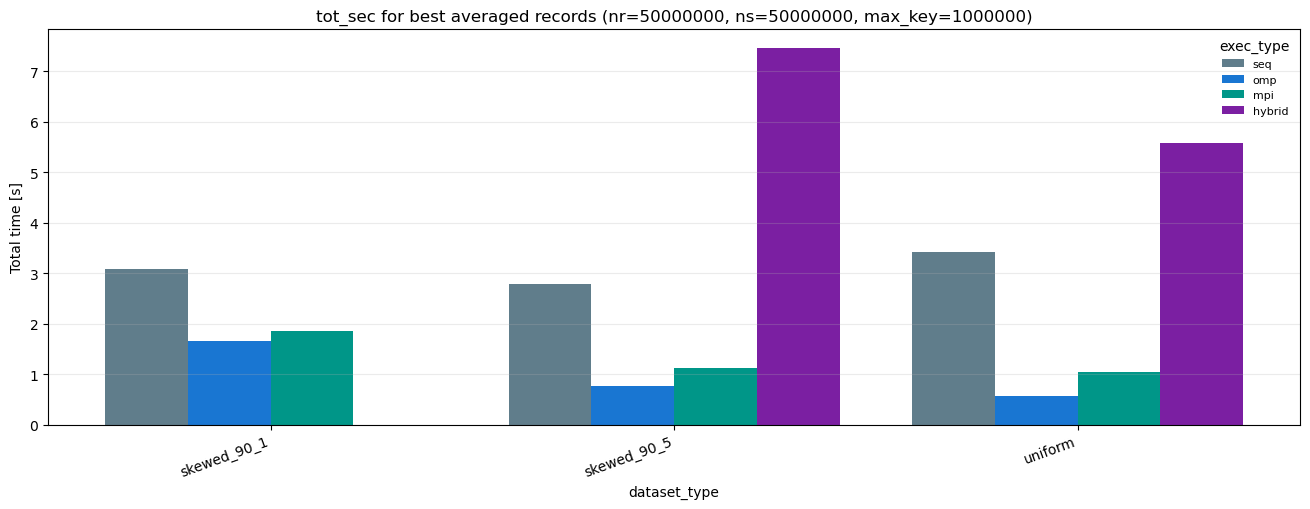

[saved] img/002_selected_best_partition_time_50000000_50000000_1000000.png


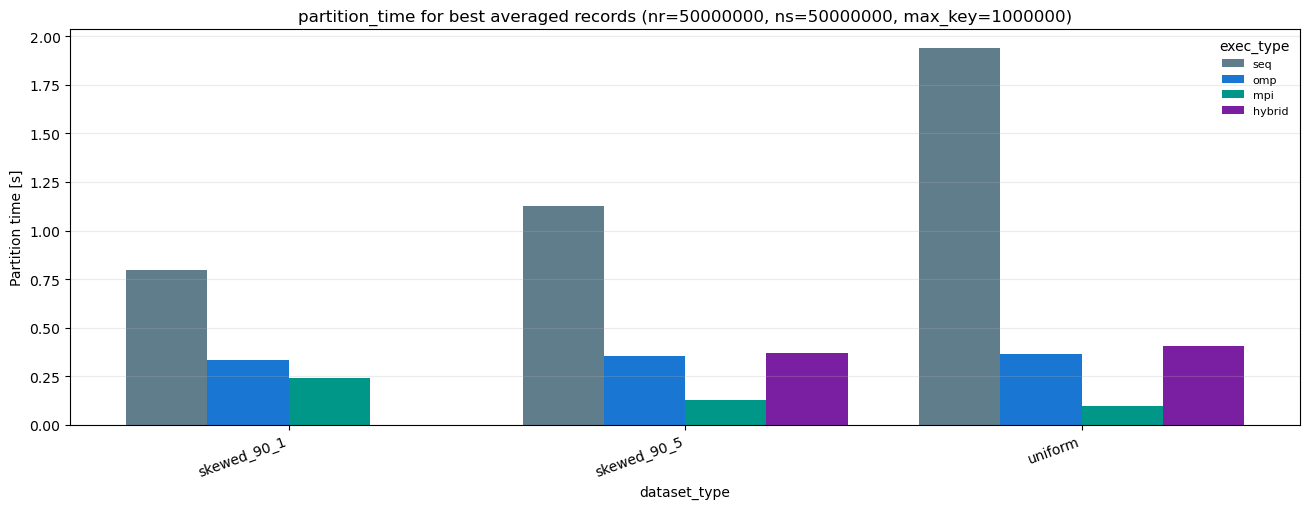

[saved] img/003_selected_best_join_time_50000000_50000000_1000000.png


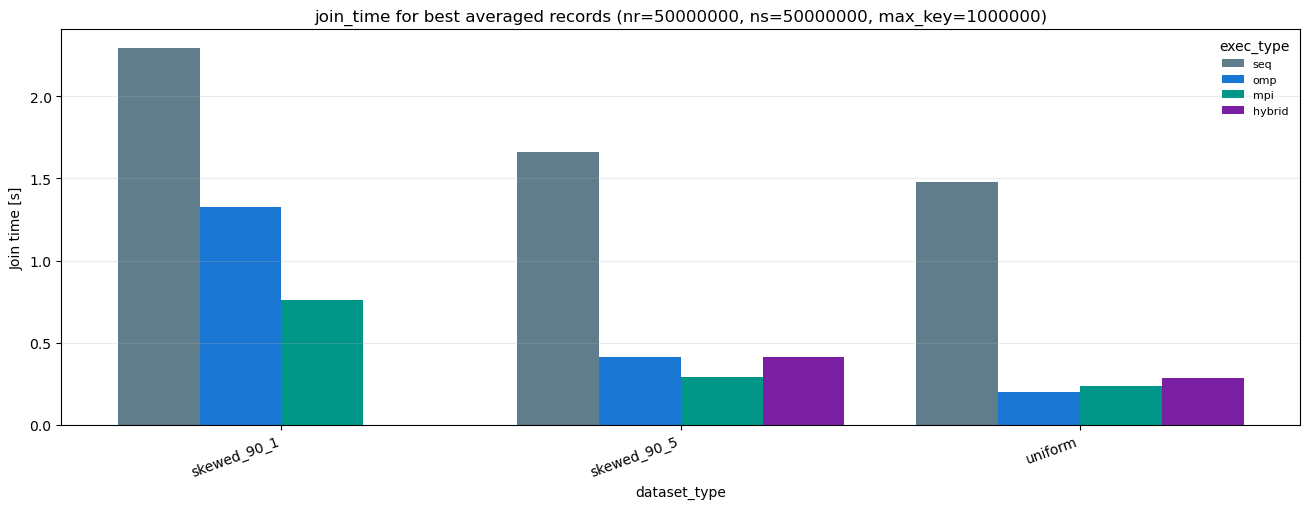

In [18]:
def plot_selected_metric(metric_df, metric_col, ylabel, title_prefix, hline=None):
    required = set(problem_columns + ["dataset_type", "exec_type", metric_col])
    missing = sorted(required - set(metric_df.columns))
    if missing:
        print(f"Skipping {metric_col}: missing columns {missing}")
        return

    plot_df = metric_df.dropna(subset=[metric_col]).copy()
    if plot_df.empty:
        print(f"Skipping {metric_col}: no valid values")
        return

    for problem_key, subdf in plot_df.groupby(problem_columns, dropna=False):
        if not isinstance(problem_key, tuple):
            problem_key = (problem_key,)
        dataset_types = ordered_values(subdf["dataset_type"])
        exec_types = ordered_values(subdf["exec_type"], EXEC_TYPE_ORDER)
        if not dataset_types or not exec_types:
            continue

        x_positions = np.arange(len(dataset_types))
        bar_width = 0.82 / max(len(exec_types), 1)
        fig, ax = plt.subplots(figsize=(max(8.8, 1.1 * len(dataset_types) * len(exec_types)), 5.2))

        for idx, exec_type in enumerate(exec_types):
            sub = subdf[subdf["exec_type"] == exec_type].set_index("dataset_type")[metric_col].to_dict()
            heights = [float(sub.get(dataset_type, np.nan)) for dataset_type in dataset_types]
            offsets = x_positions + (idx - (len(exec_types) - 1) / 2.0) * bar_width
            ax.bar(offsets, heights, width=bar_width, label=exec_type, color=color_map.get(exec_type, "tab:gray"))

        if hline is not None:
            ax.axhline(float(hline), color="black", linestyle=":", linewidth=1.2)

        ax.set_xticks(x_positions)
        ax.set_xticklabels(dataset_types, rotation=20, ha="right")
        ax.set_xlabel("dataset_type")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{title_prefix} for best averaged records ({problem_label(problem_key)})")
        ax.grid(axis="y", alpha=0.25)
        ax.legend(title="exec_type", fontsize=8, frameon=False)
        fig.tight_layout()
        show_and_save(fig, f"selected_best_{title_prefix}_{'_'.join(fmt_num(v) for v in problem_key)}")


selected_metric_specs = [
    ("tot_sec", "Total time [s]", "tot_sec"),
    ("partition_time", "Partition time [s]", "partition_time"),
    ("join_time", "Join time [s]", "join_time"),
]

for metric_col, ylabel, title_prefix in selected_metric_specs:
    plot_selected_metric(selected_best_df, metric_col, ylabel, title_prefix)


# Speedup and Phase Breakdown

[saved] img/004_selected_best_Speedup_vs_sequential_version_50000000_50000000_1000000.png


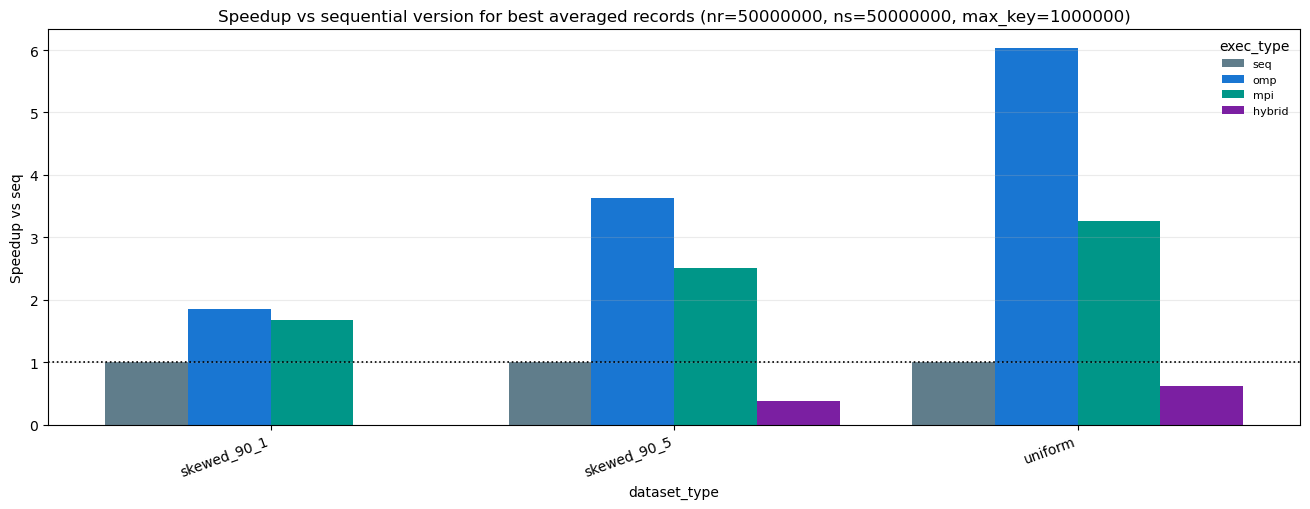

,nr,ns,max_key,dataset_type,exec_type,tot_sec,seq_tot_sec,speedup_vs_seq
0,50000000,50000000,1000000,skewed_90_1,mpi,1.847020,3.092431,1.674281
1,50000000,50000000,1000000,skewed_90_1,omp,1.664108,3.092431,1.858311
2,50000000,50000000,1000000,skewed_90_1,seq,3.092431,3.092431,1.000000
3,50000000,50000000,1000000,skewed_90_5,hybrid,7.457817,2.788284,0.373874
4,50000000,50000000,1000000,skewed_90_5,mpi,1.112531,2.788284,2.506252
5,50000000,50000000,1000000,skewed_90_5,omp,0.768023,2.788284,3.630469
6,50000000,50000000,1000000,skewed_90_5,seq,2.788284,2.788284,1.000000
7,50000000,50000000,1000000,uniform,hybrid,5.585018,3.422029,0.612716
8,50000000,50000000,1000000,uniform,mpi,1.050817,3.422029,3.256543
9,50000000,50000000,1000000,uniform,omp,0.567521,3.422029,6.029782


In [19]:
baseline_exec_type = "seq"
baseline_columns = problem_columns + ["dataset_type"]
seq_baseline = (
    selected_best_df[selected_best_df["exec_type"] == baseline_exec_type][baseline_columns + ["tot_sec"]]
    .rename(columns={"tot_sec": "seq_tot_sec"})
)

if seq_baseline.empty:
    print("[warning] No seq selected baseline available; skipping speedup_vs_seq")
    speedup_selected_df = pd.DataFrame()
else:
    speedup_selected_df = selected_best_df.merge(seq_baseline, on=baseline_columns, how="left")
    speedup_selected_df["speedup_vs_seq"] = speedup_selected_df["seq_tot_sec"] / speedup_selected_df["tot_sec"].where(speedup_selected_df["tot_sec"] > 0)
    plot_selected_metric(speedup_selected_df, "speedup_vs_seq", "Speedup vs seq", "Speedup vs sequential version", hline=1.0)

display_columns = [col for col in baseline_columns + ["exec_type", "tot_sec", "seq_tot_sec", "speedup_vs_seq"] if col in speedup_selected_df.columns]
if not speedup_selected_df.empty:
    display(speedup_selected_df[display_columns].sort_values(baseline_columns + ["exec_type"]))


[saved] img/005_selected_best_phase_breakdown_50000000_50000000_1000000.png


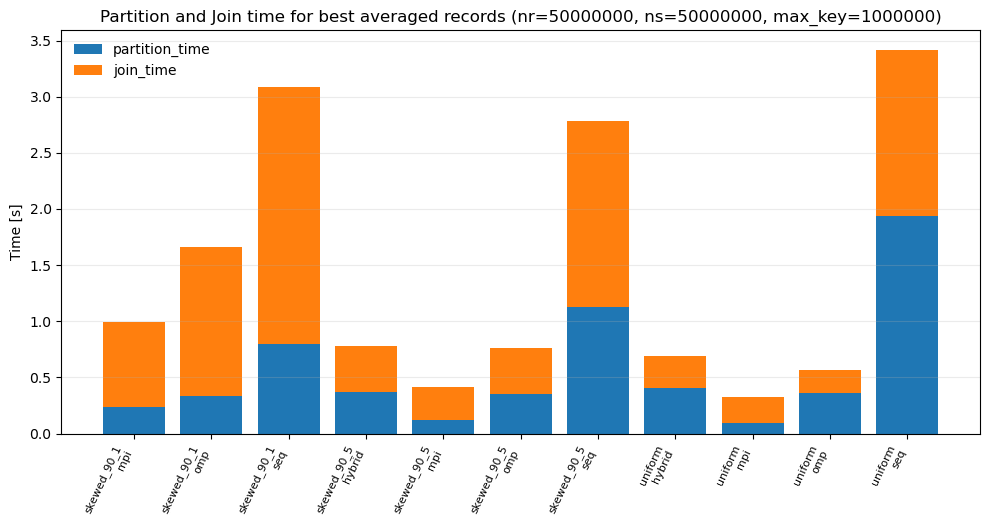

In [20]:
phase_required = set(problem_columns + ["dataset_type", "exec_type", "partition_time", "join_time"])
if phase_required.issubset(selected_best_df.columns):
    phase_df = selected_best_df.dropna(subset=["partition_time", "join_time"]).copy()
    phase_df["label"] = phase_df["dataset_type"].astype(str) + "\n" + phase_df["exec_type"].astype(str)

    for problem_key, subdf in phase_df.groupby(problem_columns, dropna=False):
        if not isinstance(problem_key, tuple):
            problem_key = (problem_key,)
        subdf = subdf.sort_values(["dataset_type", "exec_type"])
        x_positions = np.arange(len(subdf))

        fig, ax = plt.subplots(figsize=(max(10.0, 0.55 * len(subdf)), 5.4))
        ax.bar(x_positions, subdf["partition_time"], label="partition_time", color="tab:blue")
        ax.bar(x_positions, subdf["join_time"], bottom=subdf["partition_time"], label="join_time", color="tab:orange")
        ax.set_xticks(x_positions)
        ax.set_xticklabels(subdf["label"], rotation=65, ha="right", fontsize=8)
        ax.set_ylabel("Time [s]")
        ax.set_title(f"Partition and Join time for best averaged records ({problem_label(problem_key)})")
        ax.grid(axis="y", alpha=0.25)
        ax.legend(frameon=False)
        fig.tight_layout()
        show_and_save(fig, f"selected_best_phase_breakdown_{'_'.join(fmt_num(v) for v in problem_key)}")
else:
    print(f"Skipping phase breakdown: missing {sorted(phase_required - set(selected_best_df.columns))}")


# Skew Impact

[saved] img/006_selected_best_skew_penalty_vs_uniform_50000000_50000000_1000000.png


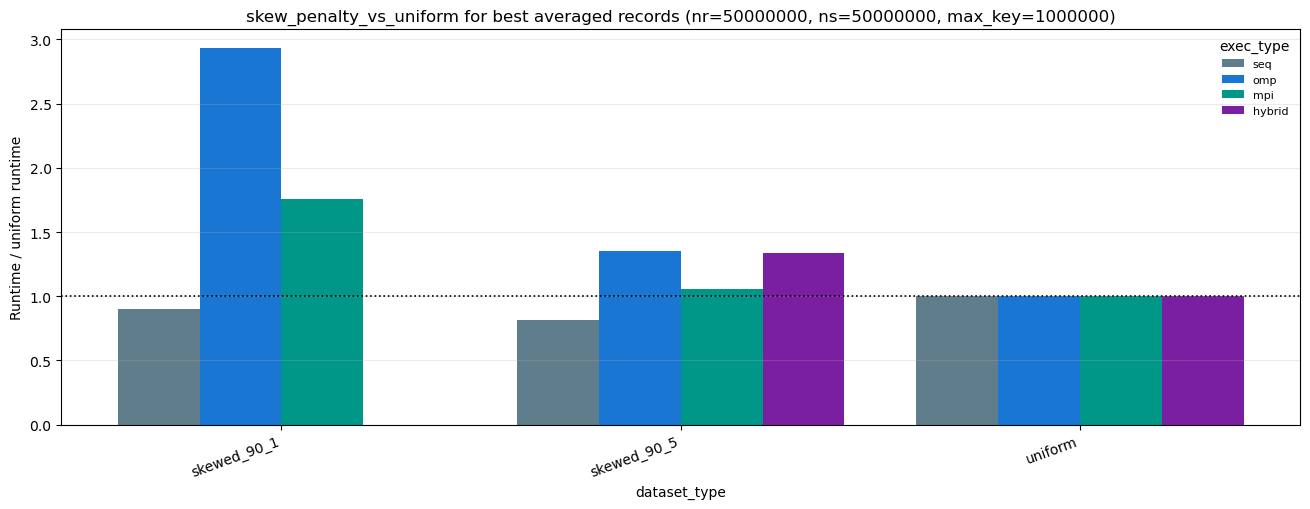

,nr,ns,max_key,dataset_type,exec_type,tot_sec,uniform_tot_sec,skew_penalty_vs_uniform
3,50000000,50000000,1000000,skewed_90_5,hybrid,7.457817,5.585018,1.335326
7,50000000,50000000,1000000,uniform,hybrid,5.585018,5.585018,1.000000
0,50000000,50000000,1000000,skewed_90_1,mpi,1.847020,1.050817,1.757700
4,50000000,50000000,1000000,skewed_90_5,mpi,1.112531,1.050817,1.058730
8,50000000,50000000,1000000,uniform,mpi,1.050817,1.050817,1.000000
1,50000000,50000000,1000000,skewed_90_1,omp,1.664108,0.567521,2.932240
5,50000000,50000000,1000000,skewed_90_5,omp,0.768023,0.567521,1.353294
9,50000000,50000000,1000000,uniform,omp,0.567521,0.567521,1.000000
2,50000000,50000000,1000000,skewed_90_1,seq,3.092431,3.422029,0.903683
6,50000000,50000000,1000000,skewed_90_5,seq,2.788284,3.422029,0.814804


In [21]:
skew_key_columns = problem_columns + ["exec_type"]
uniform_rows = selected_best_df[selected_best_df["dataset_type"] == "uniform"][skew_key_columns + ["tot_sec"]]

if uniform_rows.empty:
    print("[warning] No uniform selected records available; skipping skew impact comparison")
    skew_impact_df = pd.DataFrame()
else:
    uniform_rows = uniform_rows.rename(columns={"tot_sec": "uniform_tot_sec"})
    skew_impact_df = selected_best_df.merge(uniform_rows, on=skew_key_columns, how="left")
    skew_impact_df["skew_penalty_vs_uniform"] = skew_impact_df["tot_sec"] / skew_impact_df["uniform_tot_sec"].where(skew_impact_df["uniform_tot_sec"] > 0)
    plot_selected_metric(skew_impact_df, "skew_penalty_vs_uniform", "Runtime / uniform runtime", "skew_penalty_vs_uniform", hline=1.0)

if not skew_impact_df.empty:
    display(skew_impact_df[[col for col in problem_columns + ["dataset_type", "exec_type", "tot_sec", "uniform_tot_sec", "skew_penalty_vs_uniform"] if col in skew_impact_df.columns]].sort_values(problem_columns + ["exec_type", "dataset_type"]))


# Scaling Data Helpers

In [22]:
def existing_paths(paths):
    return [path for path in paths if path.exists()]


def load_named_csv_sources(source_specs):
    frames = []
    loaded = []
    missing = []
    for spec in source_specs:
        paths = existing_paths(spec["paths"])
        if not paths:
            missing.append(spec["name"])
            continue
        csv_path = paths[0]
        frame = normalize_frame(pd.read_csv(csv_path))
        frame["source"] = spec["name"]
        if "exec_type" not in frame.columns or frame["exec_type"].isna().all():
            frame["exec_type"] = spec.get("exec_type", csv_path.stem.replace("hashjoin_", "", 1))
        if "dataset_type" not in frame.columns:
            frame["dataset_type"] = spec.get("dataset_type", "uniform")
        frames.append(frame)
        loaded.append((spec["name"], csv_path))

    if loaded:
        print("Loaded scaling sources:")
        for name, csv_path in loaded:
            print(f"  - {name}: {csv_path}")
    if missing:
        print(f"[info] Missing scaling sources: {missing}")

    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True, sort=False)


def average_scaling_df(raw_scaling_df, extra_group_columns):
    if raw_scaling_df.empty:
        return raw_scaling_df

    group_columns = [col for col in extra_group_columns if col in raw_scaling_df.columns]
    avg_columns = [
        col for col in raw_scaling_df.columns
        if col not in group_columns and pd.api.types.is_numeric_dtype(raw_scaling_df[col])
    ]
    return (
        raw_scaling_df.groupby(group_columns, as_index=False, dropna=False)
        .agg(**{col: (col, "mean") for col in avg_columns}, n_runs=("tot_sec", "size"))
        .sort_values(group_columns)
        .reset_index(drop=True)
    )


def prepare_scaling_plot_df(raw_scaling_df, scaling_kind):
    if raw_scaling_df.empty:
        return pd.DataFrame(), None

    scaling_df = raw_scaling_df.copy()
    if "partition_threads" in scaling_df.columns and "join_threads" in scaling_df.columns:
        scaling_df = scaling_df[scaling_df["partition_threads"] == scaling_df["join_threads"]].copy()
        threads_col = "partition_threads"
    elif "partition_threads" in scaling_df.columns:
        threads_col = "partition_threads"
    elif "join_threads" in scaling_df.columns:
        threads_col = "join_threads"
    else:
        raise KeyError(f"{scaling_kind} scaling data must contain partition_threads or join_threads")

    if scaling_df.empty:
        print(f"[warning] No {scaling_kind} rows after requiring partition_threads == join_threads")
        return pd.DataFrame(), threads_col

    scaling_df["perf"] = np.nan
    if "total_throughput" in scaling_df.columns:
        scaling_df["perf"] = scaling_df["total_throughput"]
    if "tot_sec" in scaling_df.columns:
        scaling_df["perf"] = scaling_df["perf"].fillna(1.0 / scaling_df["tot_sec"].where(scaling_df["tot_sec"] > 0))

    scaling_df = scaling_df.dropna(subset=[threads_col, "perf"]).copy()
    if scaling_df.empty:
        print(f"[warning] No valid {scaling_kind} scaling performance rows")
        return pd.DataFrame(), threads_col

    group_columns = [
        "source", "exec_type", "dataset_type", "nr", "ns", "max_key", threads_col,
        "mpi_nodes", "mpi_processes", "mpi_world_size", "mpi_active_ranks", "mpi_partition_strategy",
    ]
    scaling_avg_df = average_scaling_df(scaling_df, group_columns)
    return scaling_avg_df, threads_col


def plot_scaling_bars(plot_df, threads_col, metric_col, ylabel, title, filename_prefix, group_by_n=True, series_columns=None, series_labeler=None, series_colorer=None):
    if plot_df.empty:
        print(f"Skipping {title}: no rows")
        return

    group_columns = ["nr", "ns", "max_key"] if group_by_n else []
    grouped = plot_df.groupby(group_columns, dropna=False) if group_columns else [((), plot_df)]

    for problem_key, subdf in grouped:
        if not isinstance(problem_key, tuple):
            problem_key = (problem_key,)
        thread_values = ordered_values(subdf[threads_col])
        if series_columns is None:
            series_columns = ["source", "exec_type", "dataset_type"]
        series_columns = [col for col in series_columns if col in subdf.columns]
        series_df = subdf[series_columns].drop_duplicates().sort_values(series_columns)
        series_records = series_df.to_dict("records")
        if not thread_values or not series_records:
            continue

        x_positions = np.arange(len(thread_values))
        bar_width = 0.82 / max(len(series_records), 1)
        fig, ax = plt.subplots(figsize=(max(9.5, 0.8 * len(thread_values) * len(series_records)), 5.4))

        for idx, series in enumerate(series_records):
            mask = np.ones(len(subdf), dtype=bool)
            for col, value in series.items():
                mask &= subdf[col].eq(value).to_numpy()
            series_sub = subdf[mask]
            values = series_sub.set_index(threads_col)[metric_col].to_dict()
            heights = [float(values.get(thread, np.nan)) for thread in thread_values]
            offsets = x_positions + (idx - (len(series_records) - 1) / 2.0) * bar_width
            if series_labeler is not None:
                label = series_labeler(series)
            else:
                label_parts = []
                for col in series_columns:
                    value = series[col]
                    if col in {"nr", "ns", "max_key"}:
                        label_parts.append(f"{col}={fmt_num(value)}")
                    else:
                        label_parts.append(str(value))
                label = " / ".join(label_parts)
            if series_colorer is not None:
                color = series_colorer(series)
            else:
                color = DATASET_TYPE_COLORS.get(series.get("dataset_type"), color_map.get(series.get("exec_type"), None))
            ax.bar(offsets, heights, width=bar_width, label=label, color=color, alpha=0.9)

        ax.axhline(1.0, color="black", linestyle=":", linewidth=1.2)
        ax.set_xticks(x_positions)
        ax.set_xticklabels([fmt_num(t) for t in thread_values])
        ax.set_xlabel("Number of threads (partition = join)")
        ax.set_ylabel(ylabel)
        title_suffix = f" ({problem_label(problem_key)})" if group_columns else ""
        ax.set_title(title + title_suffix)
        ax.grid(axis="y", alpha=0.25)
        ax.legend(fontsize=7, frameon=False)
        fig.tight_layout()
        suffix = "_".join(fmt_num(v) for v in problem_key) if group_columns else "all"
        show_and_save(fig, f"{filename_prefix}_{suffix}")


# Strong Scaling Comparison

Loaded scaling sources:
  - module2_cpp_threads: old_results/hashjoin_par_pj_wb_map.csv
[info] Missing scaling sources: ['module3_openmp']
[saved] img/007_strong_scaling_speedup_50000000_50000000_1000000.png


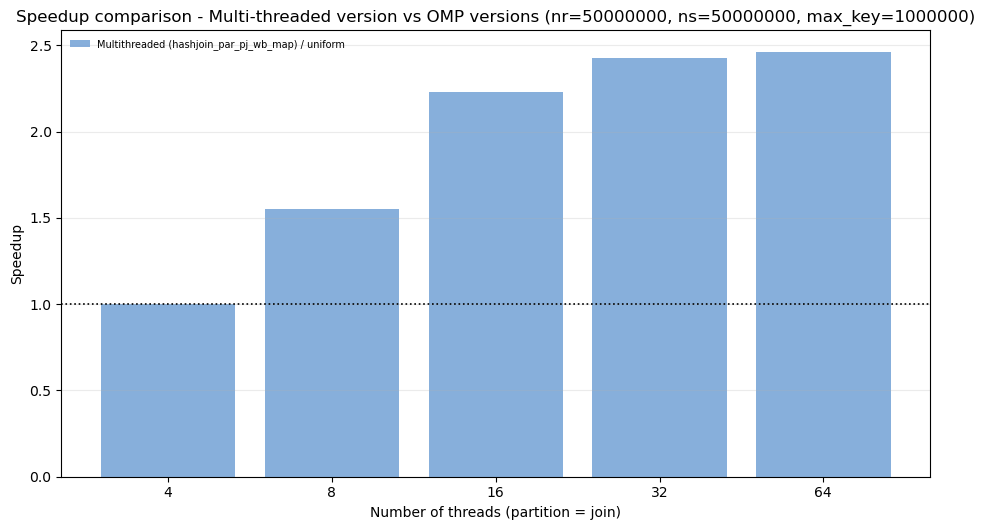

[saved] img/008_strong_scaling_efficiency_50000000_50000000_1000000.png


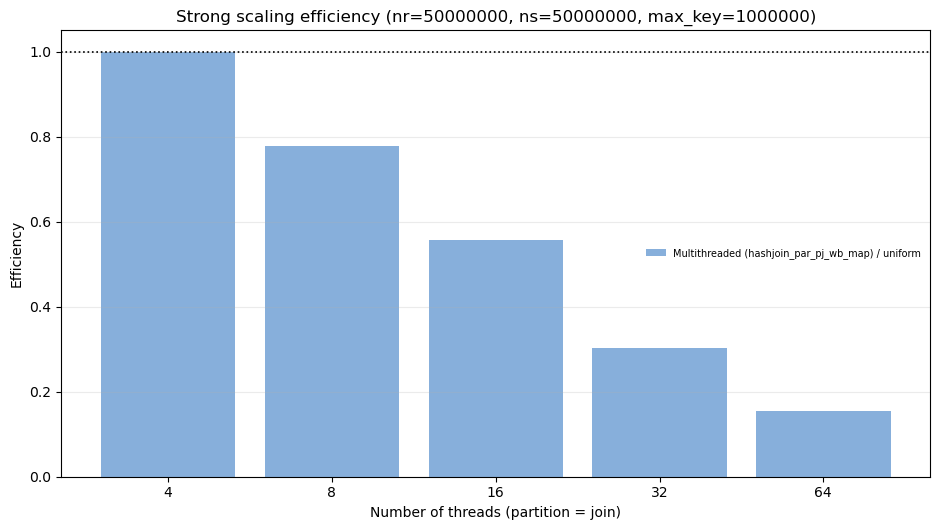

,source,exec_type,dataset_type,nr,ns,max_key,partition_threads,checksum1,checksum2,join_count,...,time_sec,total_throughput,tot_sec,perf,n_runs,baseline_thread,baseline_perf,baseline_threads,speedup,parallel_efficiency
0,module2_cpp_threads,hashjoin_par_pj_wb_map,uniform,50000000,50000000,1000000,4,6.185417e+18,1.693109e+19,2.499986e+09,...,1.355512,7.378457e+07,1.355512,7.378457e+07,5,4,7.378457e+07,4,1.000000,1.000000
1,module2_cpp_threads,hashjoin_par_pj_wb_map,uniform,50000000,50000000,1000000,8,6.185417e+18,1.693109e+19,2.499986e+09,...,0.872385,1.146291e+08,0.872385,1.146291e+08,5,4,7.378457e+07,4,1.553565,0.776783
2,module2_cpp_threads,hashjoin_par_pj_wb_map,uniform,50000000,50000000,1000000,16,6.185417e+18,1.693109e+19,2.499986e+09,...,0.610391,1.643181e+08,0.610391,1.643181e+08,5,4,7.378457e+07,4,2.226998,0.556749
3,module2_cpp_threads,hashjoin_par_pj_wb_map,uniform,50000000,50000000,1000000,32,6.185417e+18,1.693109e+19,2.499986e+09,...,0.559303,1.788460e+08,0.559303,1.788460e+08,5,4,7.378457e+07,4,2.423894,0.302987
4,module2_cpp_threads,hashjoin_par_pj_wb_map,uniform,50000000,50000000,1000000,64,6.185417e+18,1.693109e+19,2.499986e+09,...,0.550269,1.817333e+08,0.550269,1.817333e+08,5,4,7.378457e+07,4,2.463026,0.153939


In [23]:
old_results_dir = first_existing_dir(OLD_RESULTS_CANDIDATES)
strong_sources = []
if old_results_dir is not None:
    strong_sources.append({
        "name": "module2_cpp_threads",
        "paths": [old_results_dir / "hashjoin_par_pj_wb_map.csv"],
        "exec_type": "hashjoin_par_pj_wb_map",
        "dataset_type": "uniform",
    })
strong_sources.append({
    "name": "module3_openmp",
    "paths": [RESULTS_DIR / "strong_scaling.csv"],
    "exec_type": "omp",
    "dataset_type": "uniform",
})

strong_raw_df = load_named_csv_sources(strong_sources)
strong_scaling_df, strong_threads_col = prepare_scaling_plot_df(strong_raw_df, "strong")

if not strong_scaling_df.empty:
    strong_key_cols = ["source", "exec_type", "dataset_type", "nr", "ns", "max_key"]
    strong_scaling_df["baseline_thread"] = strong_scaling_df.groupby(strong_key_cols)[strong_threads_col].transform("min")
    baseline_perf = (
        strong_scaling_df[strong_scaling_df[strong_threads_col] == strong_scaling_df["baseline_thread"]]
        [strong_key_cols + ["perf", strong_threads_col]]
        .rename(columns={"perf": "baseline_perf", strong_threads_col: "baseline_threads"})
    )
    strong_scaling_df = strong_scaling_df.merge(baseline_perf, on=strong_key_cols, how="left")
    strong_scaling_df = strong_scaling_df[strong_scaling_df["baseline_perf"] > 0].copy()
    strong_scaling_df["speedup"] = strong_scaling_df["perf"] / strong_scaling_df["baseline_perf"]
    strong_scaling_df["parallel_efficiency"] = strong_scaling_df["speedup"] / (strong_scaling_df[strong_threads_col] / strong_scaling_df["baseline_threads"])

    def strong_comparison_label(series):
        prefix = "Multithreaded" if series.get("source") == "module2_cpp_threads" else "OMP"
        return f"{prefix} ({series.get('exec_type')}) / {series.get('dataset_type')}"

    def strong_comparison_color(series):
        if series.get("source") == "module2_cpp_threads":
            return "#7aa6d8"
        if series.get("dataset_type") == "uniform":
            return "#08306b"
        return DATASET_TYPE_COLORS.get(series.get("dataset_type"), color_map.get(series.get("exec_type"), None))

    plot_scaling_bars(
        strong_scaling_df,
        strong_threads_col,
        "speedup",
        "Speedup",
        "Speedup comparison - Multi-threaded version vs OMP versions",
        "strong_scaling_speedup",
        series_labeler=strong_comparison_label,
        series_colorer=strong_comparison_color,
    )
    plot_scaling_bars(
        strong_scaling_df,
        strong_threads_col,
        "parallel_efficiency",
        "Efficiency",
        "Strong scaling efficiency",
        "strong_scaling_efficiency",
        series_labeler=strong_comparison_label,
        series_colorer=strong_comparison_color,
    )
    display(strong_scaling_df.sort_values(["source", "exec_type", "dataset_type", "nr", strong_threads_col]).reset_index(drop=True))
else:
    print("No strong-scaling comparison available yet.")


# Weak Scaling Comparison

In [24]:
weak_sources = []
if old_results_dir is not None:
    weak_sources.append({
        "name": "module2_cpp_threads",
        "paths": [old_results_dir / "weak_scaling.csv"],
        "exec_type": "par_pj_wb_map",
        "dataset_type": "uniform",
    })
weak_sources.append({
    "name": "module3_openmp",
    "paths": [RESULTS_DIR / "weak_scaling.csv"],
    "exec_type": "omp",
    "dataset_type": "uniform",
})

weak_raw_df = load_named_csv_sources(weak_sources)
weak_scaling_df, weak_threads_col = prepare_scaling_plot_df(weak_raw_df, "weak")

if not weak_scaling_df.empty:
    # Match the old_statistics treatment: each N is its own series, normalized
    # to the smallest available thread count for that same source/exec/dataset/N.
    weak_key_cols = ["source", "exec_type", "dataset_type", "nr", "ns", "max_key"]
    weak_scaling_df["baseline_thread"] = weak_scaling_df.groupby(weak_key_cols)[weak_threads_col].transform("min")
    baseline_perf = (
        weak_scaling_df[weak_scaling_df[weak_threads_col] == weak_scaling_df["baseline_thread"]]
        [weak_key_cols + ["perf", weak_threads_col]]
        .rename(columns={"perf": "baseline_perf", weak_threads_col: "baseline_threads"})
    )
    weak_scaling_df = weak_scaling_df.merge(baseline_perf, on=weak_key_cols, how="left")
    weak_scaling_df = weak_scaling_df[weak_scaling_df["baseline_perf"] > 0].copy()
    weak_scaling_df["speedup"] = weak_scaling_df["perf"] / weak_scaling_df["baseline_perf"]
    weak_scaling_df["weak_efficiency"] = weak_scaling_df["speedup"] / (weak_scaling_df[weak_threads_col] / weak_scaling_df["baseline_threads"])

    weak_series_columns = ["source", "exec_type", "dataset_type", "nr"]
    plot_scaling_bars(
        weak_scaling_df,
        weak_threads_col,
        "speedup",
        "Throughput speedup",
        "Weak scaling throughput speedup by N",
        "weak_scaling_speedup_by_N",
        group_by_n=False,
        series_columns=weak_series_columns,
    )
    plot_scaling_bars(
        weak_scaling_df,
        weak_threads_col,
        "weak_efficiency",
        "Efficiency",
        "Weak scaling efficiency by N",
        "weak_scaling_efficiency_by_N",
        group_by_n=False,
        series_columns=weak_series_columns,
    )
    display(weak_scaling_df.sort_values(["source", "exec_type", "dataset_type", "nr", weak_threads_col]).reset_index(drop=True))
else:
    print("No weak-scaling comparison available yet.")


[info] Missing scaling sources: ['module2_cpp_threads', 'module3_openmp']
No weak-scaling comparison available yet.


# Interpretation Tables

In [25]:
interpretation_columns = [
    col for col in problem_columns + [
        "dataset_type", "exec_type", "tot_sec", "partition_time", "join_time",
        "redistribution_time", "redistribution_throughput",
        "total_throughput", "partition_threads", "join_threads", "partition_schedule",
        "join_schedule", "partition_block_size", "partition_task_grain",
        "join_task_grain", "offset_task_grain",
        "mpi_nodes", "mpi_processes", "mpi_world_size", "mpi_active_ranks",
        "mpi_partition_strategy",
    ] if col in selected_best_df.columns
]

best_by_dataset = selected_best_df.sort_values(problem_columns + ["dataset_type", "tot_sec"]).groupby(problem_columns + ["dataset_type"], dropna=False).head(1)
print("Fastest implementation per dataset_type:")
display(best_by_dataset[interpretation_columns].reset_index(drop=True))

if not speedup_selected_df.empty and "speedup_vs_seq" in speedup_selected_df.columns:
    print("Best selected records ranked by speedup vs sequential baseline:")
    display(speedup_selected_df.sort_values("speedup_vs_seq", ascending=False)[[col for col in interpretation_columns + ["speedup_vs_seq"] if col in speedup_selected_df.columns]].reset_index(drop=True))


Fastest implementation per dataset_type:


,nr,ns,max_key,dataset_type,exec_type,tot_sec,partition_time,join_time,redistribution_time,redistribution_throughput,...,join_schedule,partition_block_size,partition_task_grain,join_task_grain,offset_task_grain,mpi_nodes,mpi_processes,mpi_world_size,mpi_active_ranks,mpi_partition_strategy
0,50000000,50000000,1000000,skewed_90_1,omp,1.664108,0.334625,1.326118,NaN,NaN,...,guided,32768.0,NaN,NaN,NaN,1,1,NaN,NaN,block
1,50000000,50000000,1000000,skewed_90_5,omp,0.768023,0.353084,0.411525,NaN,NaN,...,guided,32768.0,NaN,NaN,NaN,1,1,NaN,NaN,block
2,50000000,50000000,1000000,uniform,omp,0.567521,0.362799,0.201371,NaN,NaN,...,guided,32768.0,NaN,NaN,NaN,1,1,NaN,NaN,block


Best selected records ranked by speedup vs sequential baseline:


,nr,ns,max_key,dataset_type,exec_type,tot_sec,partition_time,join_time,redistribution_time,redistribution_throughput,...,partition_block_size,partition_task_grain,join_task_grain,offset_task_grain,mpi_nodes,mpi_processes,mpi_world_size,mpi_active_ranks,mpi_partition_strategy,speedup_vs_seq
0,50000000,50000000,1000000,uniform,omp,0.567521,0.362799,0.201371,NaN,NaN,...,32768.0,NaN,NaN,NaN,1,1,NaN,NaN,block,6.029782
1,50000000,50000000,1000000,skewed_90_5,omp,0.768023,0.353084,0.411525,NaN,NaN,...,32768.0,NaN,NaN,NaN,1,1,NaN,NaN,block,3.630469
2,50000000,50000000,1000000,uniform,mpi,1.050817,0.093367,0.234418,0.725017,1.390158e+08,...,NaN,NaN,NaN,NaN,8,8,8.0,8.0,cyclic,3.256543
3,50000000,50000000,1000000,skewed_90_5,mpi,1.112531,0.124969,0.288222,0.698511,1.431626e+08,...,NaN,NaN,NaN,NaN,1,8,8.0,8.0,cyclic,2.506252
4,50000000,50000000,1000000,skewed_90_1,omp,1.664108,0.334625,1.326118,NaN,NaN,...,32768.0,NaN,NaN,NaN,1,1,NaN,NaN,block,1.858311
5,50000000,50000000,1000000,skewed_90_1,mpi,1.847020,0.239367,0.758421,0.849440,1.177273e+08,...,NaN,NaN,NaN,NaN,8,8,8.0,8.0,cyclic,1.674281
6,50000000,50000000,1000000,skewed_90_1,seq,3.092431,0.795621,2.294389,NaN,NaN,...,32768.0,1.0,1.0,1.0,1,1,NaN,NaN,block,1.000000
7,50000000,50000000,1000000,skewed_90_5,seq,2.788284,1.125336,1.660437,NaN,NaN,...,32768.0,1.0,1.0,1.0,1,1,NaN,NaN,block,1.000000
8,50000000,50000000,1000000,uniform,seq,3.422029,1.939422,1.480232,NaN,NaN,...,32768.0,1.0,1.0,1.0,1,1,NaN,NaN,block,1.000000
9,50000000,50000000,1000000,uniform,hybrid,5.585018,0.404415,0.283170,4.891412,2.044400e+07,...,32768.0,NaN,NaN,NaN,1,1,1.0,1.0,cyclic,0.612716


# Strong Scalability


In [26]:
strong_path = RESULTS_DIR / "strong_scaling.csv"
if not strong_path.exists():
    raise FileNotFoundError(f"Run ./strong_scaling first; missing {strong_path}")

strong_scale_df = normalize_frame(pd.read_csv(strong_path))
for col in ["nr", "ns", "max_key", "partition_threads", "join_threads", "time_sec", "total_throughput"]:
    if col in strong_scale_df.columns:
        strong_scale_df[col] = pd.to_numeric(strong_scale_df[col], errors="coerce")

strong_scale_df = strong_scale_df[strong_scale_df["partition_threads"] == strong_scale_df["join_threads"]].copy()
strong_scale_df = strong_scale_df.dropna(subset=["dataset_type", "partition_threads", "time_sec"]).copy()
if strong_scale_df.empty:
    raise ValueError("No valid strong-scaling rows available")

strong_group_cols = [
    col for col in [
        "dataset_type", "nr", "ns", "max_key", "partition_threads", "join_threads",
        "mpi_nodes", "mpi_processes", "mpi_world_size", "mpi_active_ranks", "mpi_partition_strategy",
    ] if col in strong_scale_df.columns
]
strong_scale_df = (
    strong_scale_df.groupby(strong_group_cols, as_index=False, dropna=False)
    .agg(
        time_sec=("time_sec", "mean"),
        total_throughput=("total_throughput", "mean"),
        n_runs=("time_sec", "size"),
    )
    .sort_values(["dataset_type", "partition_threads"])
    .reset_index(drop=True)
)

baseline = (
    strong_scale_df.sort_values("partition_threads")
    .groupby("dataset_type", as_index=False, dropna=False)
    .first()[["dataset_type", "partition_threads", "time_sec"]]
    .rename(columns={"partition_threads": "baseline_threads", "time_sec": "baseline_time"})
)
strong_scale_df = strong_scale_df.merge(baseline, on="dataset_type", how="left")
strong_scale_df = strong_scale_df[strong_scale_df["baseline_time"] > 0].copy()
strong_scale_df["speedup"] = strong_scale_df["baseline_time"] / strong_scale_df["time_sec"]
strong_scale_df["parallel_efficiency"] = strong_scale_df["speedup"] / (strong_scale_df["partition_threads"] / strong_scale_df["baseline_threads"])

dataset_order = [name for name in DATASET_TYPE_ORDER if name in set(strong_scale_df["dataset_type"])]
dataset_order += [name for name in ordered_values(strong_scale_df["dataset_type"]) if name not in dataset_order]
dataset_colors = DATASET_TYPE_COLORS
thread_values = ordered_values(strong_scale_df["partition_threads"], preferred=[1, 2, 4, 8, 16, 32, 64])
thread_positions = np.arange(len(thread_values))
thread_labels = [str(int(t)) for t in thread_values]
bar_width = 0.8 / max(len(dataset_order), 1)

fixed_n = int(strong_scale_df["nr"].dropna().max()) if strong_scale_df["nr"].notna().any() else None
for metric_col, ylabel, title, filename in [
    ("speedup", "Speedup vs dataset baseline", "Strong scalability speedup by dataset", "strong_scalability_speedup_by_dataset"),
    ("parallel_efficiency", "Parallel efficiency", "Strong scalability efficiency by dataset", "strong_scalability_efficiency_by_dataset"),
]:
    fig, ax = plt.subplots(figsize=(8.8, 5.2))
    for idx, dataset_type in enumerate(dataset_order):
        sub = strong_scale_df[strong_scale_df["dataset_type"] == dataset_type].set_index("partition_threads")[metric_col].to_dict()
        heights = [float(sub.get(thread, np.nan)) for thread in thread_values]
        offsets = [
            x + (idx - (len(dataset_order) - 1) / 2.0) * bar_width
            for x in thread_positions
        ]
        ax.bar(
            offsets,
            heights,
            width=bar_width,
            label=dataset_type,
            color=dataset_colors.get(dataset_type),
        )
    ax.axhline(1.0, color="black", linestyle=":", linewidth=1.2)
    ax.set_xticks(thread_positions)
    ax.set_xticklabels(thread_labels)
    ax.set_ylim(bottom=0)
    ax.set_xlabel("Threads (partition = join)")
    ax.set_ylabel(ylabel)
    if fixed_n is not None:
        ax.set_title(f"{title}, N={fixed_n:,}")
    else:
        ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="dataset_type")
    show_and_save(fig, filename)

display(strong_scale_df.reset_index(drop=True))


FileNotFoundError: Run ./strong_scaling first; missing results/strong_scaling.csv

# Weak Scalability


[saved] img/013_weak_scalability_scaled_speedup_by_dataset.png


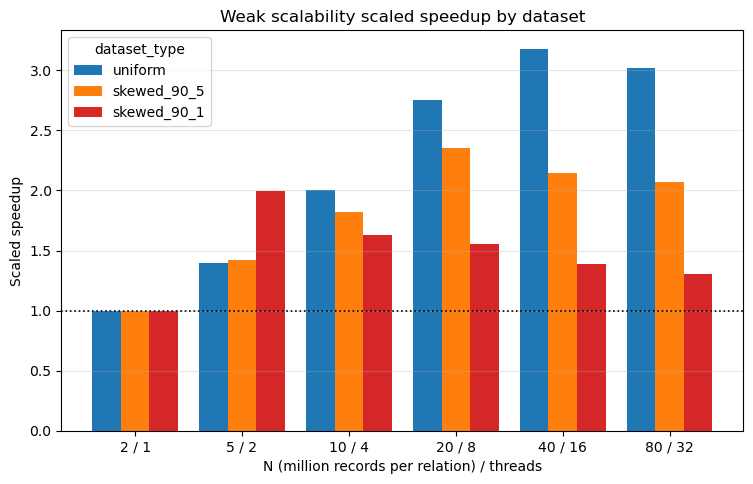

[saved] img/014_weak_scalability_efficiency_by_dataset.png


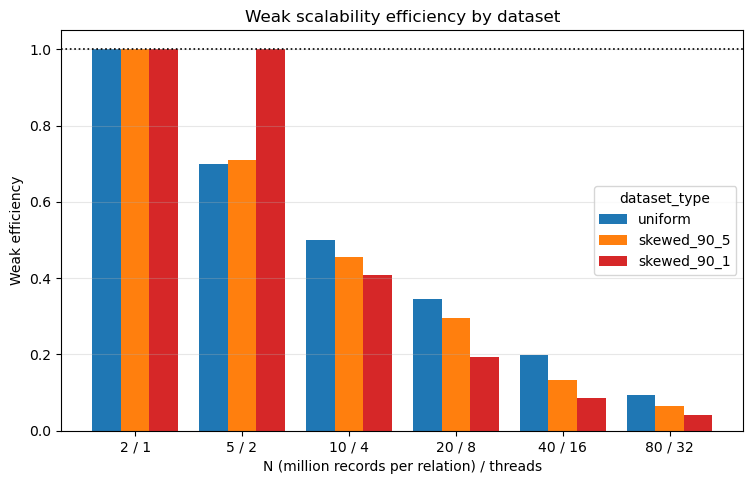

,dataset_type,nr,ns,max_key,partition_threads,join_threads,time_sec,total_throughput,n_runs,baseline_threads,baseline_time,scaled_speedup,weak_efficiency
0,skewed_90_1,2500000,2500000,1000000,1,1,0.213807,2.338660e+07,5,1,0.213807,1.000000,1.000000
1,skewed_90_1,5000000,5000000,1000000,2,2,0.213865,4.680075e+07,5,1,0.213807,1.999463,0.999732
2,skewed_90_1,10000000,10000000,1000000,4,4,0.523862,3.818258e+07,5,1,0.213807,1.632546,0.408136
3,skewed_90_1,20000000,20000000,1000000,8,8,1.101873,3.631520e+07,5,1,0.213807,1.552318,0.194040
4,skewed_90_1,40000000,40000000,1000000,16,16,2.460864,3.252817e+07,5,1,0.213807,1.390128,0.086883
5,skewed_90_1,80000000,80000000,1000000,32,32,5.245843,3.052200e+07,5,1,0.213807,1.304238,0.040757
6,skewed_90_5,2500000,2500000,1000000,1,1,0.135455,3.710245e+07,5,1,0.135455,1.000000,1.000000
7,skewed_90_5,5000000,5000000,1000000,2,2,0.191116,5.234287e+07,5,1,0.135455,1.417513,0.708757
8,skewed_90_5,10000000,10000000,1000000,4,4,0.297083,6.733983e+07,5,1,0.135455,1.823795,0.455949
9,skewed_90_5,20000000,20000000,1000000,8,8,0.459922,8.707969e+07,5,1,0.135455,2.356134,0.294517


In [ ]:
weak_path = RESULTS_DIR / "weak_scaling.csv"
if not weak_path.exists():
    raise FileNotFoundError(f"Run ./weak_scaling first; missing {weak_path}")

weak_scale_df = normalize_frame(pd.read_csv(weak_path))
for col in ["nr", "ns", "max_key", "partition_threads", "join_threads", "time_sec", "total_throughput"]:
    if col in weak_scale_df.columns:
        weak_scale_df[col] = pd.to_numeric(weak_scale_df[col], errors="coerce")

weak_scale_df = weak_scale_df[weak_scale_df["partition_threads"] == weak_scale_df["join_threads"]].copy()
weak_scale_df = weak_scale_df.dropna(subset=["dataset_type", "partition_threads", "nr", "time_sec"]).copy()
if weak_scale_df.empty:
    raise ValueError("No valid weak-scaling rows available")

weak_group_cols = [
    col for col in [
        "dataset_type", "nr", "ns", "max_key", "partition_threads", "join_threads",
        "mpi_nodes", "mpi_processes", "mpi_world_size", "mpi_active_ranks", "mpi_partition_strategy",
    ] if col in weak_scale_df.columns
]
weak_scale_df = (
    weak_scale_df.groupby(weak_group_cols, as_index=False, dropna=False)
    .agg(
        time_sec=("time_sec", "mean"),
        total_throughput=("total_throughput", "mean"),
        n_runs=("time_sec", "size"),
    )
    .sort_values(["dataset_type", "partition_threads", "nr"])
    .reset_index(drop=True)
)

baseline = (
    weak_scale_df.sort_values(["partition_threads", "nr"])
    .groupby("dataset_type", as_index=False, dropna=False)
    .first()[["dataset_type", "partition_threads", "time_sec"]]
    .rename(columns={"partition_threads": "baseline_threads", "time_sec": "baseline_time"})
)
weak_scale_df = weak_scale_df.merge(baseline, on="dataset_type", how="left")
weak_scale_df = weak_scale_df[weak_scale_df["baseline_time"] > 0].copy()

# With weak scaling, work grows with the thread count. Ideal behavior keeps time constant.
weak_scale_df["scaled_speedup"] = (weak_scale_df["partition_threads"] / weak_scale_df["baseline_threads"]) * (weak_scale_df["baseline_time"] / weak_scale_df["time_sec"])
weak_scale_df["weak_efficiency"] = weak_scale_df["baseline_time"] / weak_scale_df["time_sec"]

dataset_order = [name for name in DATASET_TYPE_ORDER if name in set(weak_scale_df["dataset_type"])]
dataset_order += [name for name in ordered_values(weak_scale_df["dataset_type"]) if name not in dataset_order]
dataset_colors = DATASET_TYPE_COLORS
case_df = (
    weak_scale_df[["nr", "partition_threads"]]
    .drop_duplicates()
    .sort_values(["partition_threads", "nr"])
    .reset_index(drop=True)
)
case_keys = list(case_df.itertuples(index=False, name=None))
case_positions = np.arange(len(case_keys))
case_labels = [f"{int(n / 1_000_000)} / {int(t)}" for n, t in case_keys]
bar_width = 0.8 / max(len(dataset_order), 1)

for metric_col, ylabel, title, filename in [
    ("scaled_speedup", "Scaled speedup", "Weak scalability scaled speedup by dataset", "weak_scalability_scaled_speedup_by_dataset"),
    ("weak_efficiency", "Weak efficiency", "Weak scalability efficiency by dataset", "weak_scalability_efficiency_by_dataset"),
]:
    fig, ax = plt.subplots(figsize=(8.8, 5.2))
    for idx, dataset_type in enumerate(dataset_order):
        sub = weak_scale_df[weak_scale_df["dataset_type"] == dataset_type].set_index(["nr", "partition_threads"])[metric_col].to_dict()
        heights = [float(sub.get(key, np.nan)) for key in case_keys]
        offsets = [
            x + (idx - (len(dataset_order) - 1) / 2.0) * bar_width
            for x in case_positions
        ]
        ax.bar(
            offsets,
            heights,
            width=bar_width,
            label=dataset_type,
            color=dataset_colors.get(dataset_type),
        )
    ax.axhline(1.0, color="black", linestyle=":", linewidth=1.2)
    ax.set_xticks(case_positions)
    ax.set_xticklabels(case_labels)
    ax.set_ylim(bottom=0)
    ax.set_xlabel("N (million records per relation) / threads")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="dataset_type")
    show_and_save(fig, filename)

display(weak_scale_df.reset_index(drop=True))
